In [6]:
import numpy as np
import matplotlib.pyplot as plt
from src.least_squares import LinearRegression, PowerLawRegression
from src.SGD import SGD, NoisyGD
from scheduled import WSDSchedule, ConstantSchedule
from src.new_schedules.polynomial import PolynomialSchedule
import src.utils as utils
from src.visualization import Visualization

from src.risk_computations import Risk


In [7]:
T=1000
sigma = 0.1
dim = 10

eta = 0.1
eta_range = np.logspace(-4, 0, 50)
t_values = np.linspace(0, T-1, 10, dtype=int)

model = PowerLawRegression(dim=dim, sigma=sigma, exponent=2)

wsd = WSDSchedule(steps=T, base_lr=eta, cooldown_len=0.2)
constant = ConstantSchedule(steps=T, base_lr=eta)
linear = WSDSchedule(steps=T, base_lr=eta, cooldown_len=1.)

x0 = np.random.multivariate_normal(np.zeros(dim), np.eye(dim))

risks = Risk(model, x0, schedules=[wsd, constant, linear], schedules_names=["wsd", "constant", "linear"], sgd_class=SGD)


In [8]:
risks.optimize_all_base_lrs(eta_range=np.logspace(-4, 0.5, 50), change_eta=True, save_results=True)

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-15_17-41-33.json


{'wsd': {'best_eta': 0.3816213407949357, 'min_risk': 0.00038602579816588383},
 'constant': {'best_eta': 0.25001103826179305,
  'min_risk': 0.0018602325835605014},
 'linear': {'best_eta': 0.5825136712468927,
  'min_risk': 0.00030663023599422797}}

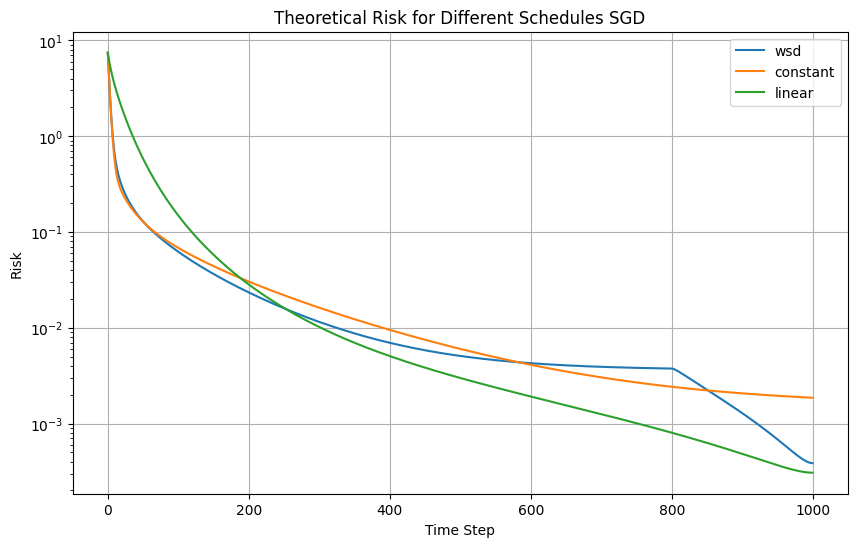

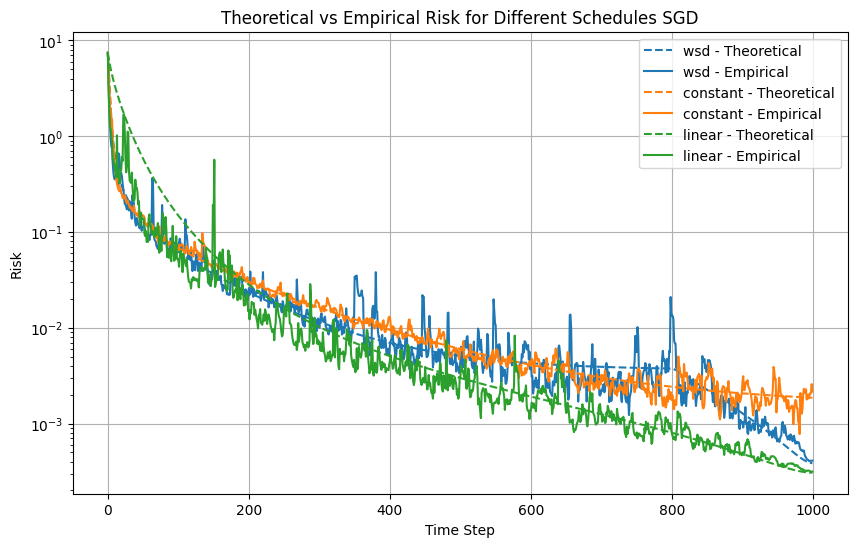

In [9]:
theoretical_risks = risks.compute_all_theoretical_risks()
all_risks = risks.compute_all_risks(n_runs=10)

visualization = Visualization([wsd, constant, linear], ["wsd", "constant", "linear"])
visualization.plot_for_every_schedule(
    theoretical_risks,
    title="Theoretical Risk for Different Schedules SGD",
    logscale=True,
    savefig=True,
    filename="Theoretical_Risk_Schedules_SGD"
    )
visualization.plot_comparison(
    all_risks["theoretical"],
    all_risks["empirical"],
    title="Theoretical vs Empirical Risk for Different Schedules SGD",
    logscale=True,
    )


In [15]:
optimization = risks.optimize_at_several_ts(t_values=np.linspace(0, 999, 20, dtype=int), eta_range=eta_range, change_eta=True, save_results=True)

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_several_ts_2026-04-15_17-43-16.json


In [16]:
print(optimization)

{0: {'wsd': {'best_eta': 0.0001, 'min_risk': 7.438759546531306}, 'constant': {'best_eta': 0.0001, 'min_risk': 7.438759546531306}, 'linear': {'best_eta': 0.0001, 'min_risk': 7.438759546531306}}, 52: {'wsd': {'best_eta': 0.32374575428176433, 'min_risk': 0.11871044857598355}, 'constant': {'best_eta': 0.32374575428176433, 'min_risk': 0.11871044857598355}, 'linear': {'best_eta': 0.32374575428176433, 'min_risk': 0.11748899658986832}}, 105: {'wsd': {'best_eta': 0.32374575428176433, 'min_risk': 0.05882548726302482}, 'constant': {'best_eta': 0.32374575428176433, 'min_risk': 0.05882548726302482}, 'linear': {'best_eta': 0.3906939937054613, 'min_risk': 0.05592926053971327}}, 157: {'wsd': {'best_eta': 0.3906939937054613, 'min_risk': 0.03410481666193904}, 'constant': {'best_eta': 0.3906939937054613, 'min_risk': 0.03410481666193904}, 'linear': {'best_eta': 0.47148663634573895, 'min_risk': 0.03182752991128393}}, 210: {'wsd': {'best_eta': 0.3906939937054613, 'min_risk': 0.02150343142697482}, 'constant'

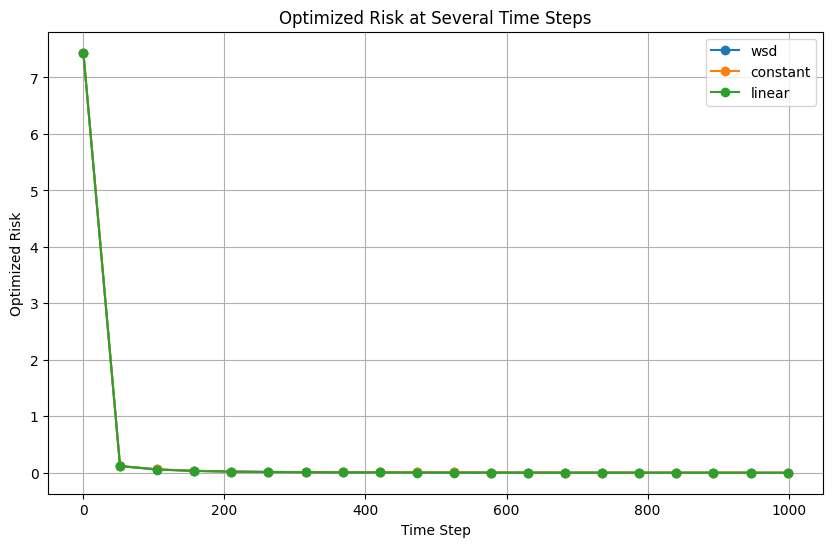

In [17]:
visualization.plot_optimization_at_several_ts(
    optimization, legend=True, savefig=False, logscale=False, filename=None)

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarning: overflow encountered in multiply
  v_t = P_t_vector * v_t + noise_t


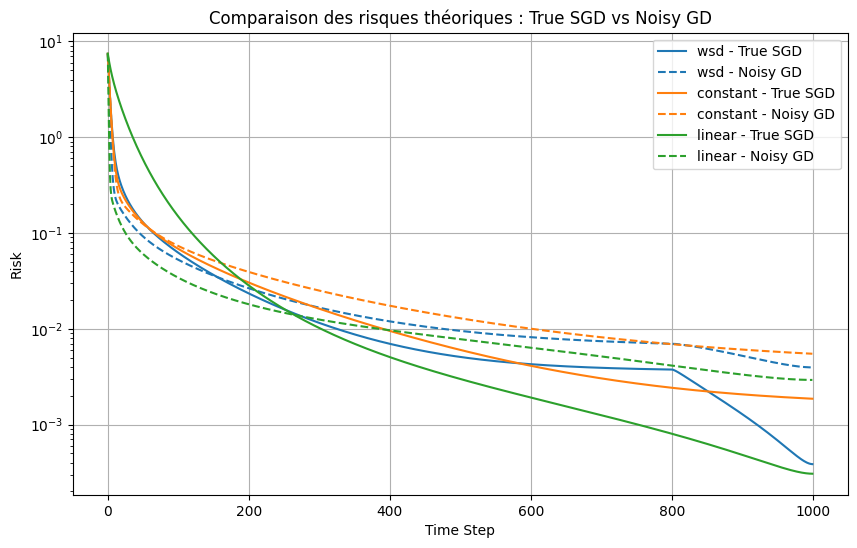

In [13]:
import copy

schedules_names = ["wsd", "constant", "linear"]
schedules = [wsd, constant, linear]
schedules_noisy = [copy.deepcopy(schedule) for schedule in schedules]

risk_computation_sgd = Risk(model, x0, schedules, schedules_names, sgd_class=SGD)
risk_computation_noisy = Risk(model, x0, schedules_noisy, schedules_names, sgd_class=NoisyGD)

risk_computation_sgd.optimize_all_base_lrs(eta_range=np.logspace(-4, 0.5, 50), change_eta=True, save_results=False)
risk_computation_noisy.optimize_all_base_lrs(eta_range=np.logspace(-4, 0.5, 50), change_eta=True, save_results=False)

risks_sgd_data = risk_computation_sgd.compute_all_theoretical_risks()
risks_noisy_data = risk_computation_noisy.compute_all_theoretical_risks()


visu = Visualization(schedules, schedules_names)

visu.plot_sgd_classes_comparison(
    risks_class1=risks_sgd_data, 
    risks_class2=risks_noisy_data, 
    label_class1=SGD.name,       # Récupère "True SGD"
    label_class2=NoisyGD.name,   # Récupère "Noisy GD"
    title="Comparaison des risques théoriques : True SGD vs Noisy GD",
    logscale=True,
    savefig=True
)